<a href="https://colab.research.google.com/github/iisratislam/Generative_Modeling_Case-Study/blob/main/part2_cicids_gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN Case Study — Part 2.2: Synthetic Network Traffic with CICIDS 2017

We use a GAN to generate synthetic **network traffic feature vectors** (not
images) from the CICIDS 2017 dataset. Unlike the image DCGANs, this uses
fully-connected networks to model tabular data.

Steps:
1. Load and explore the Wednesday file (BENIGN + DoS traffic); examine
   features and class balance.
2. Preprocess: clean invalid values, select numeric features, scale them.
3. Build a fully-connected GAN that generates feature vectors.
4. Train it and monitor loss curves.
5. Use PCA / t-SNE to compare real vs. generated feature distributions.
6. Evaluate how well the synthetic data matches the real distribution.

Reference: Goodfellow et al. (2014), original GAN.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Load the Wednesday CSV from My Drive
CSV_PATH = "/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv"
df = pd.read_csv(CSV_PATH)

print("\nDataframe shape:", df.shape)
print("First few columns:", list(df.columns[:5]))

Using device: cuda
Mounted at /content/drive

Dataframe shape: (692703, 79)
First few columns: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets']


## 1. Explore the data: features and class balance

The Wednesday file contains BENIGN traffic plus several DoS attack types. We
inspect the label column, the class distribution, and the numeric feature
columns. CICIDS CSVs are known to have quirks — leading/trailing whitespace in
column names, and infinite/NaN values — which we'll need to handle.

Label column values:

Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


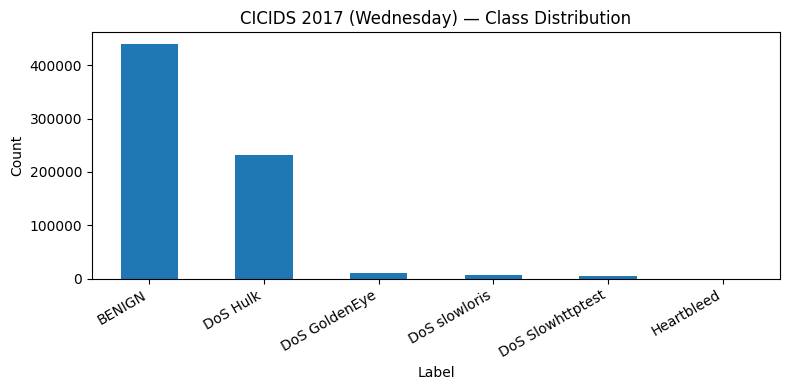

In [2]:
# Strip leading/trailing whitespace from all column names (CICIDS quirk)
df.columns = df.columns.str.strip()

# The label column is called 'Label'
print("Label column values:\n")
print(df["Label"].value_counts())

# Plot class distribution
plt.figure(figsize=(8, 4))
df["Label"].value_counts().plot(kind="bar")
plt.title("CICIDS 2017 (Wednesday) — Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 2. Preprocess the data

CICIDS 2017 CSVs require cleaning before modelling:
1. Drop the 11 Heartbleed rows (a non-DoS outlier with too few samples).
2. Replace infinite values (from divide-by-zero flow calculations) with NaN,
   then drop rows containing NaN.
3. Keep only numeric feature columns (drop the label for GAN training).
4. Scale features to a fixed range so the GAN trains stably — we use
   MinMax scaling to [-1, 1] to match a Tanh generator output.

In [3]:
from sklearn.preprocessing import MinMaxScaler

def preprocess_cicids(df):
    """
    Cleans and prepares the CICIDS Wednesday data for GAN training.

    Steps:
      1. Drop the tiny Heartbleed class (non-DoS outlier).
      2. Replace inf with NaN, then drop rows with NaN.
      3. Separate numeric features from the label.
      4. Drop zero-variance (constant) columns — they carry no information.
      5. MinMax-scale features to [-1, 1].

    Returns:
        scaled_features (np.ndarray, float32), the fitted scaler, and the
        list of feature column names kept.
    """
    data = df.copy()

    # 1. Drop Heartbleed rows
    data = data[data["Label"] != "Heartbleed"]

    # 2. Replace inf with NaN and drop NaN rows
    data = data.replace([np.inf, -np.inf], np.nan)
    data = data.dropna()

    # 3. Separate features (all numeric columns) from the label
    feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    X = data[feature_cols].astype(np.float32)

    # 4. Drop constant (zero-variance) columns
    non_constant = X.columns[X.std() > 0]
    X = X[non_constant]
    feature_cols = list(non_constant)

    # 5. Scale to [-1, 1]
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_scaled = scaler.fit_transform(X).astype(np.float32)

    return X_scaled, scaler, feature_cols


X_scaled, scaler, feature_cols = preprocess_cicids(df)

print("Processed feature matrix shape:", X_scaled.shape)
print("Number of features kept:", len(feature_cols))
print("Value range:", X_scaled.min(), "to", X_scaled.max())

Processed feature matrix shape: (691395, 68)
Number of features kept: 68
Value range: -1.0 to 1.0000001


## 3. Build the tabular GAN

Because the data is tabular (feature vectors, not images), we use
fully-connected networks rather than convolutions:

- **Generator**: maps a noise vector to a 68-dimensional feature vector, with
  BatchNorm + ReLU between layers and a Tanh output (matching the [-1, 1]
  scaled data).
- **Discriminator**: maps a 68-dimensional vector to a real/fake logit, using
  LeakyReLU and dropout for regularisation.

In [4]:
class Generator(nn.Module):
    """
    Tabular GAN generator: maps a noise vector to an `out_dim`-dimensional
    feature vector. Fully-connected with BatchNorm + ReLU; Tanh output to
    match the [-1, 1] scaled features.
    """
    def __init__(self, noise_dim=64, hidden_dim=256, out_dim=68):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(True),
            nn.Linear(hidden_dim, out_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """
    Tabular GAN discriminator: maps a feature vector to a real/fake logit.
    Fully-connected with LeakyReLU and dropout for regularisation; no sigmoid
    (we use BCEWithLogitsLoss).
    """
    def __init__(self, in_dim=68, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

## 4. Create DataLoader and models

We wrap the scaled features in a DataLoader for batched training and
instantiate the generator and discriminator. Because the dataset is large
(~690k rows), even a few epochs give the GAN plenty of data to learn from.

In [5]:
from torch.utils.data import TensorDataset, DataLoader

# Wrap features in a DataLoader
X_tensor = torch.from_numpy(X_scaled)
dataset = TensorDataset(X_tensor)
BATCH_SIZE = 512
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Create models
NOISE_DIM = 64
FEATURE_DIM = X_scaled.shape[1]   # 68

gen = Generator(noise_dim=NOISE_DIM, hidden_dim=256, out_dim=FEATURE_DIM).to(device)
disc = Discriminator(in_dim=FEATURE_DIM, hidden_dim=256).to(device)

# Shape check
z = torch.randn(8, NOISE_DIM, device=device)
fake = gen(z)
print("Generator output shape:", fake.shape)       # expect (8, 68)
print("Discriminator output shape:", disc(fake).shape)  # expect (8, 1)

Generator output shape: torch.Size([8, 68])
Discriminator output shape: torch.Size([8, 1])


## 5. Train the GAN

We train with the standard GAN objective (`BCEWithLogitsLoss`) and Adam
(lr = 0.0002, betas = (0.5, 0.999)). Because the dataset is large, a handful of
epochs already exposes the GAN to hundreds of thousands of samples. We track
generator and discriminator losses per epoch.

In [6]:
def train_tabular_gan(gen, disc, dataloader, noise_dim=64,
                      n_epochs=15, lr=2e-4, log_every=1):
    """
    Trains a fully-connected GAN on tabular feature vectors using the standard
    GAN objective (BCEWithLogitsLoss). Tracks generator/discriminator losses
    per epoch.

    Returns (g_losses, d_losses).
    """
    criterion = nn.BCEWithLogitsLoss()
    opt_g = torch.optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))

    g_losses, d_losses = [], []

    for epoch in range(n_epochs):
        epoch_g, epoch_d, n_batches = 0.0, 0.0, 0

        for (real_batch,) in dataloader:
            real_batch = real_batch.to(device)
            b_size = real_batch.size(0)

            real_labels = torch.ones(b_size, 1, device=device)
            fake_labels = torch.zeros(b_size, 1, device=device)

            # ---- Train Discriminator ----
            z = torch.randn(b_size, noise_dim, device=device)
            fake_batch = gen(z)

            d_real = criterion(disc(real_batch), real_labels)
            d_fake = criterion(disc(fake_batch.detach()), fake_labels)
            d_loss = d_real + d_fake

            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()

            # ---- Train Generator ----
            g_loss = criterion(disc(fake_batch), real_labels)

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

            epoch_g += g_loss.item()
            epoch_d += d_loss.item()
            n_batches += 1

        g_losses.append(epoch_g / n_batches)
        d_losses.append(epoch_d / n_batches)

        if (epoch + 1) % log_every == 0:
            print(f"Epoch {epoch+1}/{n_epochs} | D loss: {d_losses[-1]:.4f} "
                  f"| G loss: {g_losses[-1]:.4f}")

    return g_losses, d_losses

In [7]:
N_EPOCHS = 15

g_losses, d_losses = train_tabular_gan(
    gen, disc, train_loader, noise_dim=NOISE_DIM, n_epochs=N_EPOCHS
)

print("Training complete.")

Epoch 1/15 | D loss: 1.2786 | G loss: 0.7910
Epoch 2/15 | D loss: 1.3098 | G loss: 0.8069
Epoch 3/15 | D loss: 1.3165 | G loss: 0.7976
Epoch 4/15 | D loss: 1.3200 | G loss: 0.7955
Epoch 5/15 | D loss: 1.3205 | G loss: 0.7942
Epoch 6/15 | D loss: 1.3246 | G loss: 0.7904
Epoch 7/15 | D loss: 1.3273 | G loss: 0.7874
Epoch 8/15 | D loss: 1.3251 | G loss: 0.7886
Epoch 9/15 | D loss: 1.3233 | G loss: 0.7907
Epoch 10/15 | D loss: 1.3184 | G loss: 0.7963
Epoch 11/15 | D loss: 1.3161 | G loss: 0.8025
Epoch 12/15 | D loss: 1.3112 | G loss: 0.8085
Epoch 13/15 | D loss: 1.3066 | G loss: 0.8163
Epoch 14/15 | D loss: 1.3011 | G loss: 0.8244
Epoch 15/15 | D loss: 1.2956 | G loss: 0.8321
Training complete.


## 6. Evaluate: loss curves and distribution comparison (PCA / t-SNE)

Since the data is high-dimensional (68 features), we can't plot it directly.
Instead we use **dimensionality reduction** to project real and generated
feature vectors into 2D and check whether they overlap:

- **PCA** — a fast linear projection onto the directions of greatest variance.
- **t-SNE** — a slower non-linear method that preserves local structure,
  often revealing clusters more clearly.

Good overlap between real and generated points indicates the GAN has learned
the real feature distribution.

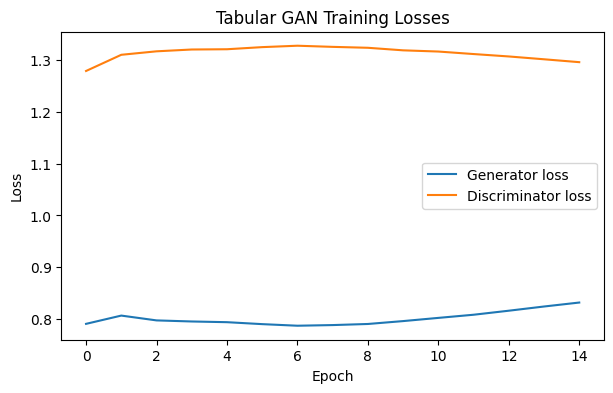

Synthetic shape: (5000, 68)
Real sample shape: (5000, 68)


In [8]:
def plot_gan_losses(g_losses, d_losses, title="Tabular GAN Training Losses"):
    """Plots generator and discriminator loss curves per epoch."""
    plt.figure(figsize=(7, 4))
    plt.plot(g_losses, label="Generator loss")
    plt.plot(d_losses, label="Discriminator loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(title); plt.legend()
    plt.show()


plot_gan_losses(g_losses, d_losses)

# Generate a batch of synthetic feature vectors for comparison
N_COMPARE = 5000

gen.eval()
with torch.no_grad():
    z = torch.randn(N_COMPARE, NOISE_DIM, device=device)
    synthetic = gen(z).cpu().numpy()
gen.train()

# Take an equal-sized random sample of real data for a fair comparison
rng = np.random.default_rng(0)
real_idx = rng.choice(X_scaled.shape[0], size=N_COMPARE, replace=False)
real_sample = X_scaled[real_idx]

print("Synthetic shape:", synthetic.shape)
print("Real sample shape:", real_sample.shape)

Explained variance: PC1 = 0.506, PC2 = 0.175 (total 0.680)


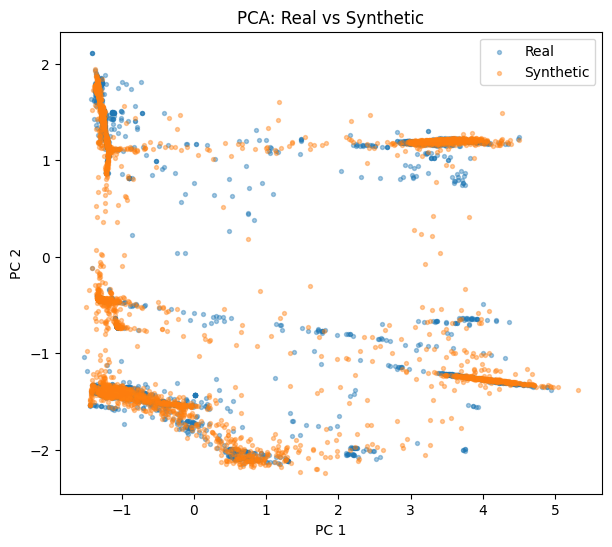

In [9]:
from sklearn.decomposition import PCA

def plot_pca_comparison(real, synthetic, title="PCA: Real vs Synthetic"):
    """
    Fits PCA on the real data, projects both real and synthetic vectors into
    2D, and overlays them to check distribution overlap.
    """
    pca = PCA(n_components=2)
    real_2d = pca.fit_transform(real)          # fit on real
    synth_2d = pca.transform(synthetic)        # project synthetic into same space

    plt.figure(figsize=(7, 6))
    plt.scatter(real_2d[:, 0], real_2d[:, 1], s=8, alpha=0.4, label="Real")
    plt.scatter(synth_2d[:, 0], synth_2d[:, 1], s=8, alpha=0.4, label="Synthetic")
    plt.title(title)
    plt.xlabel("PC 1"); plt.ylabel("PC 2")
    plt.legend()
    var = pca.explained_variance_ratio_
    print(f"Explained variance: PC1 = {var[0]:.3f}, PC2 = {var[1]:.3f} "
          f"(total {var.sum():.3f})")
    plt.show()


plot_pca_comparison(real_sample, synthetic)

## 7. t-SNE comparison

t-SNE is a non-linear projection that preserves local neighbourhood structure,
often separating clusters more clearly than PCA. Because t-SNE is
computationally expensive, we run it on a smaller subsample of real and
synthetic points.

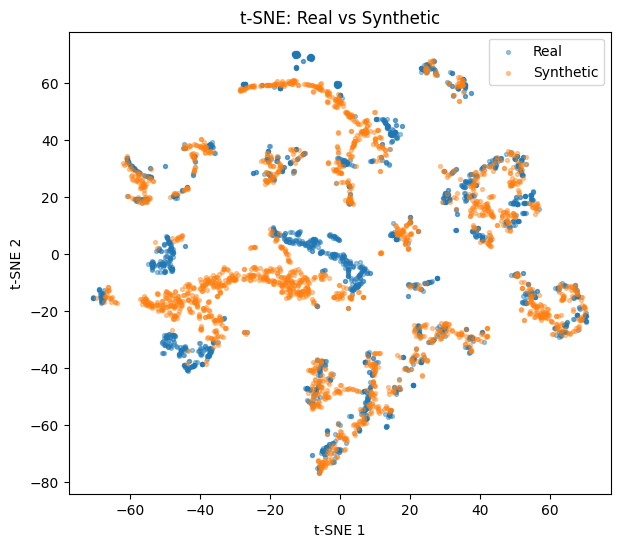

In [10]:
from sklearn.manifold import TSNE

def plot_tsne_comparison(real, synthetic, n=2000, title="t-SNE: Real vs Synthetic"):
    """
    Runs t-SNE on a combined subsample of real and synthetic vectors, then
    plots them coloured by source to check overlap. t-SNE is slow, so we
    subsample to n points each.
    """
    real_sub = real[:n]
    synth_sub = synthetic[:n]

    combined = np.vstack([real_sub, synth_sub])
    labels = np.array([0] * len(real_sub) + [1] * len(synth_sub))  # 0=real, 1=synth

    # Fit t-SNE on the combined set so both share the same embedding
    tsne = TSNE(n_components=2, random_state=0, init="pca", perplexity=30)
    embedded = tsne.fit_transform(combined)

    plt.figure(figsize=(7, 6))
    plt.scatter(embedded[labels == 0, 0], embedded[labels == 0, 1],
                s=8, alpha=0.4, label="Real")
    plt.scatter(embedded[labels == 1, 0], embedded[labels == 1, 1],
                s=8, alpha=0.4, label="Synthetic")
    plt.title(title)
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.legend()
    plt.show()


plot_tsne_comparison(real_sample, synthetic, n=2000)